In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set_style("whitegrid")

from pathlib import Path

# Exploratory Data Analysis (EDA)

1. Check Missing Values & Data Consistency

In [2]:
dataset_path = Path("research_centers.csv")

# research center quality dataframe 
rcq_df = pd.read_csv(dataset_path)

print("Research center quality data preview: \n", rcq_df.head(3))

Research center quality data preview: 
   researchCenterId  researchCenterName    city  latitude  longitude  \
0           RC-014  Research Center 14  City 4   50.7713    -1.9260   
1           RC-040  Research Center 40  City 2   50.5088    -1.3637   
2           RC-031  Research Center 31  City 4   50.2202    -1.2889   

   internalFacilitiesCount  hospitals_10km  pharmacies_10km  \
0                        3               1                0   
1                        2               1                1   
2                        3               0                1   

   facilityDiversity_10km  facilityDensity_10km  
0                0.374488              0.177506  
1                0.391903              0.108965  
2                0.293552              0.076155  


In [3]:
# Dataset info, showing non-null count and data types
print(rcq_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   researchCenterId         50 non-null     str    
 1   researchCenterName       50 non-null     str    
 2   city                     50 non-null     str    
 3   latitude                 50 non-null     float64
 4   longitude                50 non-null     float64
 5   internalFacilitiesCount  50 non-null     int64  
 6   hospitals_10km           50 non-null     int64  
 7   pharmacies_10km          50 non-null     int64  
 8   facilityDiversity_10km   50 non-null     float64
 9   facilityDensity_10km     50 non-null     float64
dtypes: float64(4), int64(3), str(3)
memory usage: 4.0 KB
None


In [4]:
# Describe data
print(rcq_df.describe())

        latitude  longitude  internalFacilitiesCount  hospitals_10km  \
count  50.000000  50.000000                50.000000       50.000000   
mean   50.542770  -1.554638                 5.660000        1.860000   
std     0.320289   0.253853                 3.146816        1.340271   
min    50.007100  -1.976900                 1.000000        0.000000   
25%    50.240375  -1.747225                 3.000000        1.000000   
50%    50.635350  -1.561000                 5.000000        2.000000   
75%    50.831475  -1.374175                 8.750000        3.000000   
max    50.994600  -1.049300                11.000000        4.000000   

       pharmacies_10km  facilityDiversity_10km  facilityDensity_10km  
count        50.000000               50.000000             50.000000  
mean          2.240000                0.568843              0.321164  
std           1.684988                0.249511              0.182562  
min           0.000000                0.119515              0.05654

A more detailed statistical overview of the dataset, including measures such as the mean, standard deviation, and other relevant summary metrics. Overall, the numerical features appear tightly clustered around their means, as indicated by relatively small standard deviation values across columns (excluding categorical variables).


In [5]:
rows, columns = rcq_df.shape
print(f"Dataset has {rows} rows, and {columns} columns")

print("\nDuplicates:", rcq_df.duplicated().sum())

print("\nPercentage of missing values per column:")
print(rcq_df.isnull().sum()/rows*100)

Dataset has 50 rows, and 10 columns

Duplicates: 0

Percentage of missing values per column:
researchCenterId           0.0
researchCenterName         0.0
city                       0.0
latitude                   0.0
longitude                  0.0
internalFacilitiesCount    0.0
hospitals_10km             0.0
pharmacies_10km            0.0
facilityDiversity_10km     0.0
facilityDensity_10km       0.0
dtype: float64


No missing or duplicate values were identified, so no preprocessing was required for these aspects. If such issues had been present, appropriate handling strategies would have been applied.

In [6]:
for col in rcq_df.columns:
    unique_vals = rcq_df[col].unique()
    print(f"Column: {col}")
    print(f"Unique values ({len(unique_vals)}): {unique_vals}\n")

Column: researchCenterId
Unique values (50): <StringArray>
['RC-014', 'RC-040', 'RC-031', 'RC-046', 'RC-018', 'RC-049', 'RC-027',
 'RC-026', 'RC-033', 'RC-020', 'RC-013', 'RC-005', 'RC-038', 'RC-009',
 'RC-004', 'RC-007', 'RC-042', 'RC-047', 'RC-048', 'RC-016', 'RC-010',
 'RC-017', 'RC-025', 'RC-035', 'RC-032', 'RC-001', 'RC-045', 'RC-028',
 'RC-034', 'RC-006', 'RC-030', 'RC-012', 'RC-037', 'RC-002', 'RC-022',
 'RC-003', 'RC-044', 'RC-036', 'RC-024', 'RC-041', 'RC-011', 'RC-023',
 'RC-019', 'RC-050', 'RC-021', 'RC-008', 'RC-043', 'RC-015', 'RC-029',
 'RC-039']
Length: 50, dtype: str

Column: researchCenterName
Unique values (50): <StringArray>
['Research Center 14', 'Research Center 40', 'Research Center 31',
 'Research Center 46', 'Research Center 18', 'Research Center 49',
 'Research Center 27', 'Research Center 26', 'Research Center 33',
 'Research Center 20', 'Research Center 13',  'Research Center 5',
 'Research Center 38',  'Research Center 9',  'Research Center 4',
  'Research C

Unique values were assessed to identify potential categorical inconsistencies (e.g., variations such as ‘City 1’, ‘city1’, or ‘city 1’) and to check for any other obvious data entry errors.


2. Visualize Facility Counts, Diversity, and Density

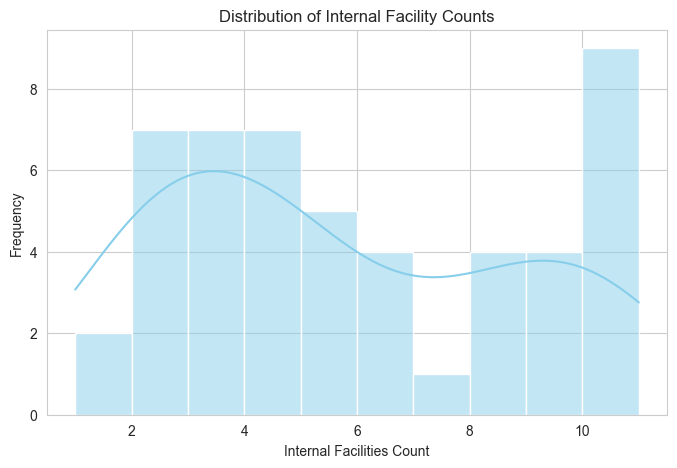

In [7]:
# Histogram of internal facility counts.
plt.figure(figsize=(8,5))
sns.histplot(rcq_df['internalFacilitiesCount'], bins=10, kde=True, color='skyblue')
plt.title("Distribution of Internal Facility Counts")
plt.xlabel("Internal Facilities Count")
plt.ylabel("Frequency")
plt.show()

The histogram shows a **bimodal distribution** of internal facility counts, with two distinct peaks and slight skewness. This suggests the presence of two underlying subgroups or processes influencing the variable, rather than a single homogeneous distribution.


Outlier check and clustering implication

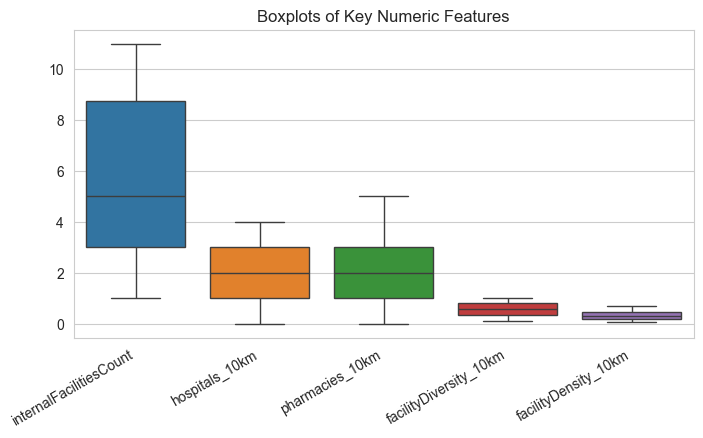

In [8]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=rcq_df[[
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km",
    "facilityDiversity_10km",
    "facilityDensity_10km"
]])
plt.title("Boxplots of Key Numeric Features")
plt.xticks(rotation=30, ha="right")
plt.show()

Although no strong statistical outliers are observed, 
internalFacilitiesCount shows a wider spread compared to other features. 

This reinforces the importance of feature scaling before applying K-Means, 
as features with larger variance could disproportionately influence clustering.

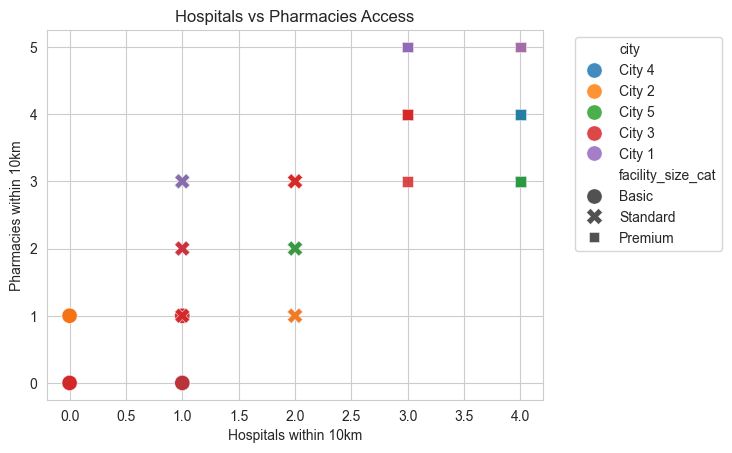

In [9]:
# Scatter plots showing hospital and pharmacy access
rcq_df_sp = rcq_df.copy()
rcq_df_sp["facility_size_cat"] = pd.cut(
    rcq_df_sp["internalFacilitiesCount"],
    bins=[0, 3, 7, 11],
    labels=["Basic", "Standard", "Premium"]
)

sns.scatterplot(
    data=rcq_df_sp,
    x="hospitals_10km",
    y="pharmacies_10km",
    hue="city",
    style="facility_size_cat",
    palette="tab10",
    s=120,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.4,
)

plt.title("Hospitals vs Pharmacies Access")
plt.xlabel("Hospitals within 10km")
plt.ylabel("Pharmacies within 10km")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

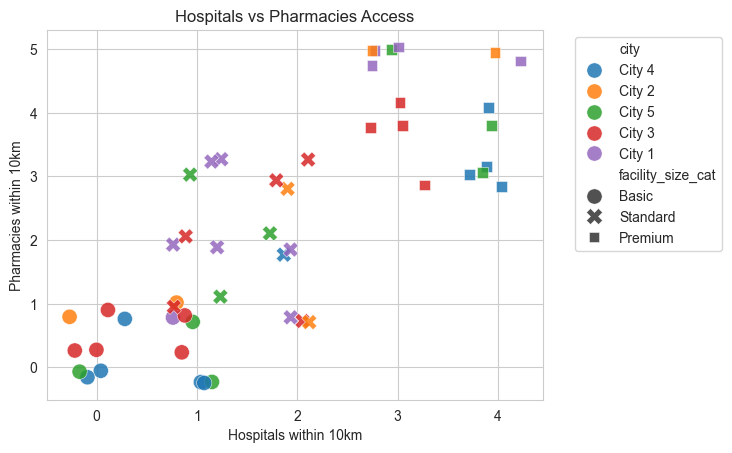

In [10]:
# Add jitter manually
rcq_df_jitter = rcq_df_sp.copy()
rcq_df_jitter["hospitals_10km"] += np.random.uniform(-0.3, 0.3, size=len(rcq_df))
rcq_df_jitter["pharmacies_10km"] += np.random.uniform(-0.3, 0.3, size=len(rcq_df))

sns.scatterplot(
    data=rcq_df_jitter,
    x="hospitals_10km",
    y="pharmacies_10km",
    hue="city",
    style="facility_size_cat",
    palette="tab10",
    s=120,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.4,
)

plt.title("Hospitals vs Pharmacies Access")
plt.xlabel("Hospitals within 10km")
plt.ylabel("Pharmacies within 10km")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The scatterplot indicates two positive relationships: one between the number of pharmacies and hospitals, and another between these counts (pharmacies/hospitals) and internal facility count. 

This suggests that areas with more healthcare services tend to also have higher internal facility counts (further backed by correlaton heatmap).

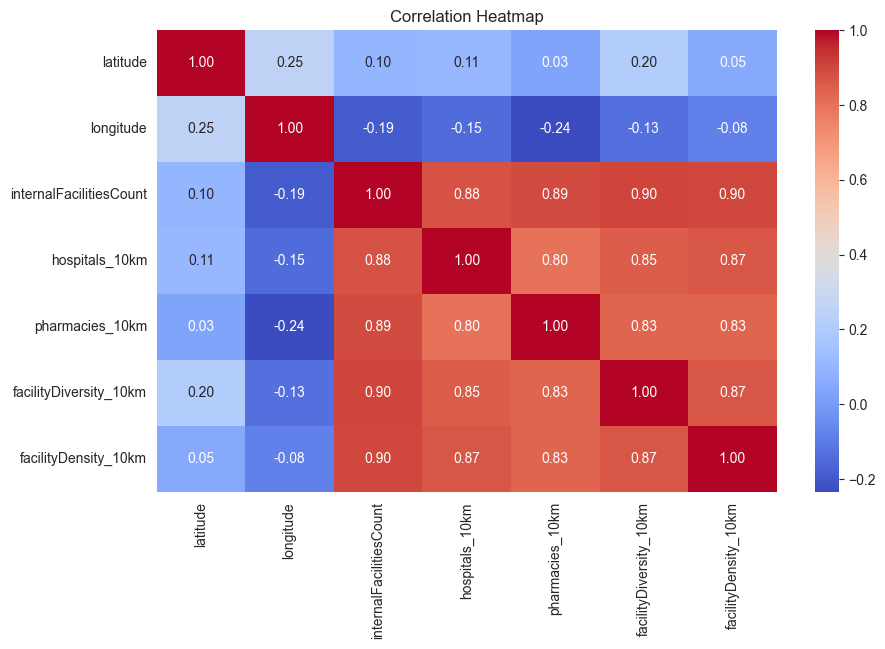

In [11]:
# Correlation heatmap of numeric columns.
numeric_cols = rcq_df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Feature Selection

1. Why were these features selected?

Since no labels are available for quality tiers (e.g., premium, standard, basic), we use features correlated with internal facility count as proxies to infer the likely quality of a research center. This is based on the assumption that a richer surrounding ecosystem is indicative of higher research center quality.

In [12]:
df_features = rcq_df.copy()

# Candidate list 
features = [
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km",
    "facilityDiversity_10km",
    "facilityDensity_10km"
]

# Subset
df_features = df_features[features]
df_features.head()

,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,3,1,0,0.374488,0.177506
1,2,1,1,0.391903,0.108965
2,3,0,1,0.293552,0.076155
3,11,4,4,0.884502,0.697016
4,10,4,5,0.842611,0.568983


2. Which features have the highest correlation with overall facility diversity or quality?

The features most strongly correlated with overall facility quality are `facilityDiversity_10km` and `facilityDensity_10km`. While `hospitals_10km` and `pharmacies_10km` also show high correlation and variance, their variance primarily reflects the absolute number of nearby facilities rather than the diversity of services, and therefore does not fully capture the overall richness of the ecosystem.

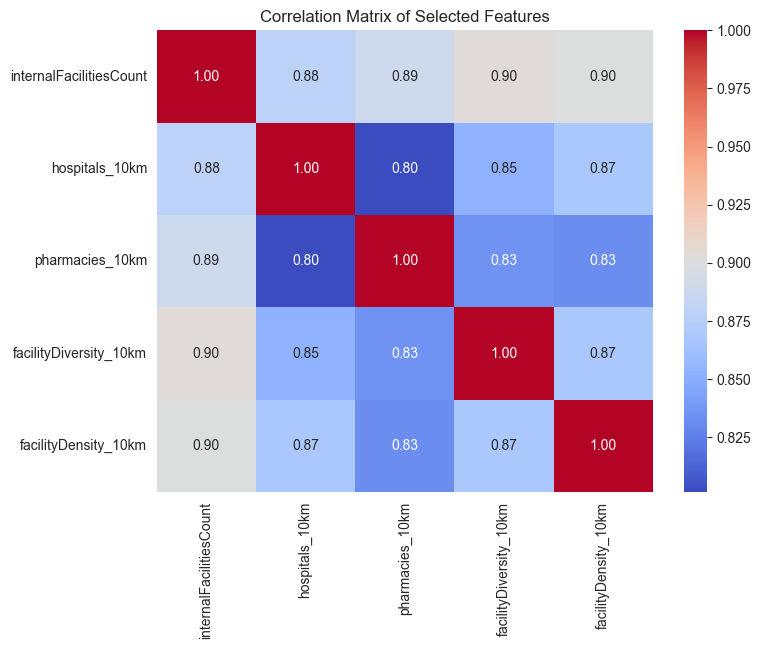

Correlation with internalFacilitiesCount:
internalFacilitiesCount    1.000000
facilityDiversity_10km     0.903568
facilityDensity_10km       0.900576
pharmacies_10km            0.889402
hospitals_10km             0.878828
Name: internalFacilitiesCount, dtype: float64

Variance with internalFacilitiesCount:
internalFacilitiesCount    9.902449
hospitals_10km             1.796327
pharmacies_10km            2.839184
facilityDiversity_10km     0.062256
facilityDensity_10km       0.033329
dtype: float64


In [13]:
# Compute correlation matrix
corr_matrix = df_features.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Selected Features")
plt.show()

# Correlation with internalFacilitiesCount 
print("Correlation with internalFacilitiesCount:")
print(corr_matrix["internalFacilitiesCount"].sort_values(ascending=False))

# Variances 
variances = df_features.var()
print("\nVariance with internalFacilitiesCount:")
print(variances)

# Clustering Model

1. Setup

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Copy the dataframe
rcq_df_clust = rcq_df.copy()

# Features selected based on correlation analysis
features = [
    "internalFacilitiesCount",
    "facilityDiversity_10km",
    "facilityDensity_10km"
]

X = rcq_df_clust[features]

2. Standardise training data

In [15]:
# ensures that all features contribute equally to distance-based algorithms, 
# preventing features with larger scales from dominating the calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

3. Apply K-mean clustering (k=3)

In [16]:
# Initialize K-Means
rcq_segmentation_model = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit the model
rcq_df_clust['cluster'] = rcq_segmentation_model.fit_predict(X_scaled)

# Evaluate clustering quality
sil_score = silhouette_score(X_scaled, rcq_df_clust['cluster'])
print(f"Silhouette Score: {sil_score:.3f}")

Silhouette Score: 0.596


Silhouette score ranges from -1 to 1:

- `1` points are well matched to their own cluster and far from others (good clustering)
- `0` points are on or very close to the decision boundary between clusters (indeterminate clustering)
- `-1` points may be assigned to the wrong cluster (poor clustering)

So, a higher silhouette score indicates better-defined clusters.

4. Map Cluster Numbers to Descriptive Labels

Since K-Means assigns arbitrary cluster numbers, we map them based on average internalFacilitiesCount per cluster:

In [17]:
# Compute cluster means for sorting
cluster_order = rcq_df_clust.groupby('cluster')['internalFacilitiesCount'].mean().sort_values(ascending=False).index

# Map cluster numbers to labels
cluster_labels = {cluster_order[0]: "Premium",
                  cluster_order[1]: "Standard",
                  cluster_order[2]: "Basic"}

rcq_df_clust['cluster_label'] = rcq_df_clust['cluster'].map(cluster_labels)

# View results
rcq_df_clust[['researchCenterName', 'internalFacilitiesCount', 'cluster', 'cluster_label']].head(10)

,researchCenterName,internalFacilitiesCount,cluster,cluster_label
0,Research Center 14,3,1,Basic
1,Research Center 40,2,1,Basic
2,Research Center 31,3,1,Basic
3,Research Center 46,11,2,Premium
4,Research Center 18,10,2,Premium
5,Research Center 49,4,0,Standard
6,Research Center 27,1,1,Basic
7,Research Center 26,8,2,Premium
8,Research Center 33,2,1,Basic
9,Research Center 20,2,1,Basic


5. Visualise clusters

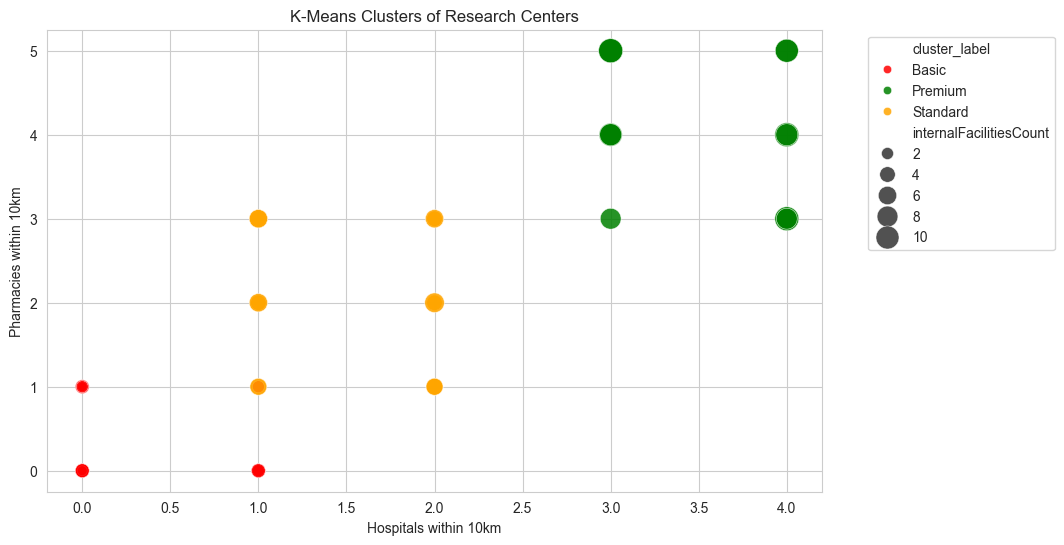

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=rcq_df_clust,
    x="hospitals_10km",
    y="pharmacies_10km",
    hue="cluster_label",
    size="internalFacilitiesCount",
    palette=["red", "green", "orange"],  # Premium=green, Standard=orange, Basic=red
    sizes=(50, 300),
    alpha=0.85,
    edgecolor="white",
    linewidth=0.4
)
plt.title("K-Means Clusters of Research Centers")
plt.xlabel("Hospitals within 10km")
plt.ylabel("Pharmacies within 10km")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

6. Model Interpretation

In [19]:
cluster_summary = rcq_df_clust.groupby('cluster_label')[features].mean().sort_values(by='internalFacilitiesCount', ascending=False)
cluster_summary

,internalFacilitiesCount,facilityDiversity_10km,facilityDensity_10km
cluster_label,,,
Premium,9.529412,0.850424,0.536852
Standard,4.941176,0.559935,0.289845
Basic,2.312500,0.279126,0.125271


1. Which cluster has the highest internal facility counts and external healthcare access?
Cluster 0 (labelled Premium) has the highest internal facility count (~9.5) and external healthcare access (hospitals ~3.5, pharmacies ~4.1).

2. Are high-quality centers concentrated in specific cities?
Premium centers are concentrated in specific cities with dense ecosystems and strong infrastructure (e.g., City 1 and City 4), unlike Standard and Basic centers.

3. Does diversity or density play a stronger role?
Both facility diversity and density increase with cluster quality. However, diversity shows higher values and a larger gap between Premium and Basic clusters (0.85-0.28 = 0.57) compared to density (0.54-0.13 = 0.41), indicating diversity plays a slightly stronger role in differentiating quality.

Summary:
Clustering effectively separates research centers into quality tiers. Internal facility count and facility diversity are the key drivers of quality, and high-quality centers are geographically concentrated, highlighting the importance of city-level infrastructure in supporting research excellence.

7. Save model scaler and cluster labels

In [20]:
model_bundle = {
    "model": rcq_segmentation_model,
    "scaler": scaler,
    "labels": cluster_labels
}

joblib.dump(model_bundle, "models/research_center_pipeline.pkl")

['models/research_center_pipeline.pkl']

# Impact of Feature Selection on Clustering Performance

A test was conducted to compare clustering performance using three feature sets:

- Features with highest variance

- All strongly correlated features

- Strongest features (preselected, previously achieving a Silhouette Score of 0.596)

The goal is to evaluate how feature selection based on variance versus correlation versus targeted strongest predictors affects cluster quality.

In [21]:
# Copy the dataframe
rcq_df_clust_test = rcq_df.copy()

# Features selected based on correlation analysis
strongly_correlated_features = [
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km",
    "facilityDiversity_10km",
    "facilityDensity_10km"
    ]

highest_variance_features = [
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km"
    ] 


def evaluate_kmeans(features: list[str]) -> None:
    X = rcq_df_clust_test[features]
    # reusing scaler
    X_scaled = scaler.fit_transform(X)
    # Initialize K-Means
    rcq_segmentation_model = KMeans(n_clusters=3, random_state=42, n_init=10)

    # Fit the model
    rcq_df_clust['cluster'] = rcq_segmentation_model.fit_predict(X_scaled)

    # Evaluate clustering quality
    sil_score = silhouette_score(X_scaled, rcq_df_clust['cluster'])
    print(f"Silhouette Score: {sil_score:.3f}")
    

In [22]:
evaluate_kmeans(strongly_correlated_features)

Silhouette Score: 0.552


In [23]:
evaluate_kmeans(highest_variance_features)

Silhouette Score: 0.526
